In [1]:
import pathlib
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import pandas as pd
import pingouin as pg
import seaborn as sns


import TwoPUtils as tpu
import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42


%matplotlib inline

%load_ext autoreload
%autoreload 2
 

In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig1_licks')
figdir.mkdir(exist_ok=True, parents=True)

In [3]:

def make_behavior_dataframe(key, mean=False, omit_only =False, norm=False, rzone_ledge=5):
    rows = []
    x = np.arange(-10,3)
    for (cond, mice) in zip(('ctrl', 'ko', 'sparse'), (ctrl_mice, ko_mice, sparse_mice)):
        for day in range(6):
            
            print(day)
            for mouse in mice:

                if mouse == 'SparseKO_09' and day==2:
                    continue
                print(mouse)
                sess = stx.utilities.load_vr_day(mouse, day,verbose = False, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/', trial_mat_keys=['licks', 
                                                                                                                                    'licks_sum', 
                                                                                                                                    'nonconsum_licks', 
                                                                                                                                    'consum_licks', 
                                                                                                                                    'licks_rate', 
                                                                                                                                    'speed', 
                                                                                                                                    'reward', 'acc'])
                # if se
                # sess.novel_arm = stx.ymaze_sess_deets['']

                bin_edges = sess.trial_matrices['bin_edges']
                right_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
                left_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

                if sess.novel_arm==-1:
                    rzone_nov = left_rzone_front
                    rzone_fam = right_rzone_front
                else:
                    rzone_nov = right_rzone_front
                    rzone_fam = left_rzone_front

                for ttype in ('fam', 'nov'):
                    
                    if ttype == 'nov':
                        trial_mask = sess.trial_info["LR"] == sess.novel_arm
                        rzone = rzone_nov
                    else:
                        trial_mask = sess.trial_info["LR"] != sess.novel_arm
                        rzone = rzone_fam

                    if omit_only:
                        trial_mask = trial_mask & (np.nansum(sess.trial_matrices['reward'],axis=1)==0)

                    
                    licks = sess.trial_matrices[key][trial_mask,:]

                    if norm:
                        licks = licks/np.nanmean(licks.ravel())

                    if mean:
                        rzone_dat = np.nanmean(licks[:,rzone-rzone_ledge:rzone+1], axis=0).mean()
                    else:
                        rzone_dat = np.nanmean(licks[:,rzone-rzone_ledge:rzone+1], axis=0).sum()


                    rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)

                    rows.append({'cond': cond,
                                'mouse': mouse,
                                'day': day,
                                'ttype': ttype,
                                'rzone_dat': rzone_dat,
                                'rzone_plot_vec': rzone_plot_vec,
                                })
    return pd.DataFrame(rows)
                    
                

In [17]:
def plot_each_day(df, key, maxy=10, save=True, omit_only=True):
    for day in range(6):

        x = np.arange(-10,3)
        fig, ax =plt.subplots(1,2, sharey=True, sharex=True, figsize=[6,3])


        for cond, color in zip(('ctrl', 'ko', 'sparse'), ('black','red', 'purple')):
            for i, ttype in enumerate(('fam', 'nov')):

                mask = (df['cond']==cond) * (df['day']==day) * (df['ttype']==ttype)

                licks = np.vstack(df.loc[mask,'rzone_plot_vec'].values)


                mu, sem = np.nanmean(licks, axis=0), sp.stats.sem(licks, axis=0, nan_policy='omit')
                ax[i].plot(x, mu, color=color)
                ax[i].fill_between(x, mu-sem, mu+sem, color=color, alpha=.4)

        for a in ax.flatten():
            a.fill_betweenx([0,maxy], 0, 2, alpha=.4, color='purple', zorder=-10)
            a.spines['top'].set_visible(False)
            a.spines['right'].set_visible(False)

            a.set_ylabel(key)
            a.set_xlabel('Distance to reward')
        ax[0].set_title('Familiar')
        ax[1].set_title('Novel')
        if save:
            if omit_only:
                fig.suptitle("Probe Trials Only")
                fig.savefig(figdir / f"{key}_v_position_day{day}_omitOnly.pdf")
            else:
                
                fig.savefig(figdir / f"{key}_v_position_day{day}.pdf")

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


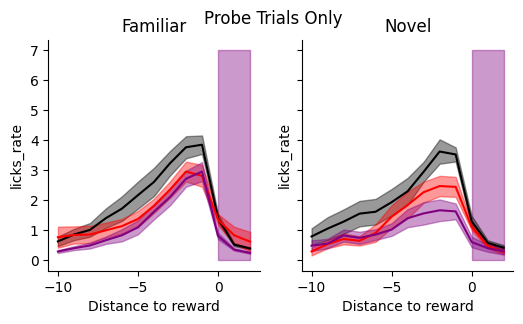

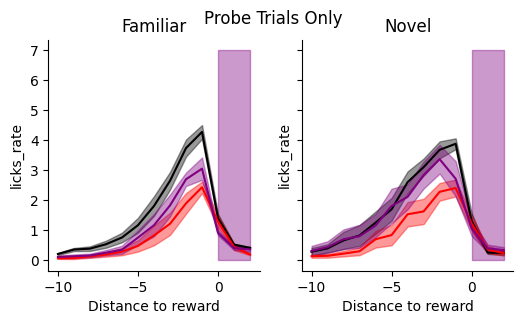

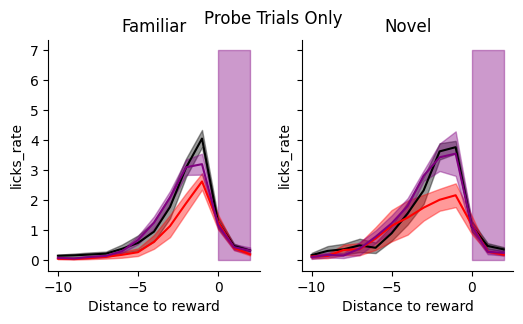

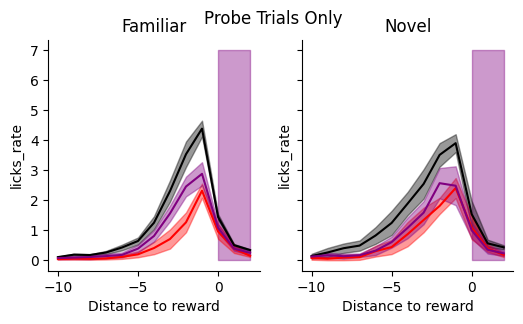

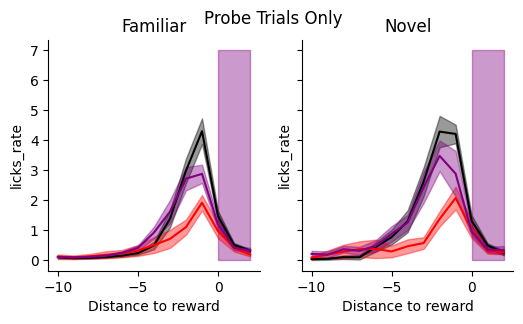

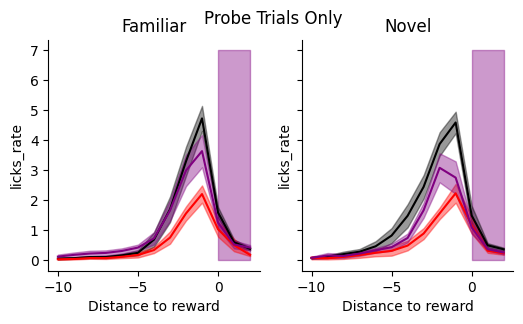

In [5]:
df = make_behavior_dataframe('licks_rate', mean=True)
plot_each_day(df,'licks_rate', maxy=7)

Text(0, 0.5, 'lick rate')

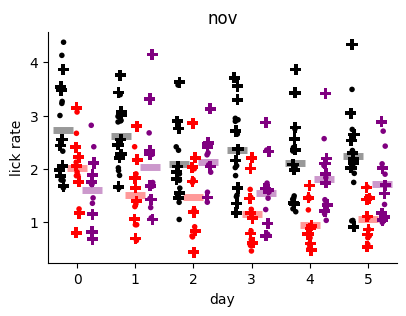

In [6]:


fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='rzone_dat',
                hue='cond', 
                hue_order=('ctrl', 'ko','sparse'), 
                palette=['black', 'red','purple'],
                dodge=True,
                ax=ax, marker = marker, s=s,
                legend=False)
    


sns.pointplot(data=df,
            x='day',
            y='rzone_dat',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko', 'sparse'],
            dodge = .5,
            palette = ['black', 'red', 'purple'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
ax.set_title(nov)

# for a in ax:
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('lick rate')


# fig.savefig(figdir / "lick_rate_summary.pdf")


In [7]:
import statsmodels.formula.api as smf

df['rank_lick_rate'] = df['rzone_dat'].rank()
mdl = smf.mixedlm('rank_lick_rate ~   C(day) + C(ttype) + C(cond)', df, groups=df['mouse'])
mdl_result = mdl.fit()

mdl_result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
              Mixed Linear Model Regression Results
=================================================================
Model:               MixedLM  Dependent Variable:  rank_lick_rate
No. Observations:    274      Method:              REML          
No. Groups:          23       Scale:               2949.0095     
Min. group size:     10       Log-Likelihood:      -1472.4773    
Max. group size:     12       Converged:           Yes           
Mean group size:     11.9                                        
-----------------------------------------------------------------
                   Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
-----------------------------------------------------------------
Intercept          200.367   16.579 12.086 0.000  167.873 232.861
C(day)[T.1]         -5.826   11.323 -0.515 0.607  -28.019  16.367
C(day)[T.2]        -21.942   11.474 -1.912 0.056  -44.431   0.546
C(day)[T.3]        -40.087   11.323 -3.540 0.000  -62.280 -17.894
C(day)[T.4]        -47.109   11.323 -4.160 0.000  -69.302 -24.915
C(day)[T.5]        -41.587   11.323 -3.673 0.000  -63.780 -19.394
C(ttype)[T.nov]     15.394    6.561  2.346 0.019    2.534  28.254
C(cond)[T.ko]      -95.115   21.939 -4.336 0.000 -138.114 -52.116
C(cond)[T.sparse]  -52.095   21.962 -2.372 0.018  -95.140  -9.051
Group Var         1649.370   11.498                              
=================================================================

"""

Shapiro-Wilk: W=0.996, p=0.622
D'Agostino: χ²=1.240, p=0.538


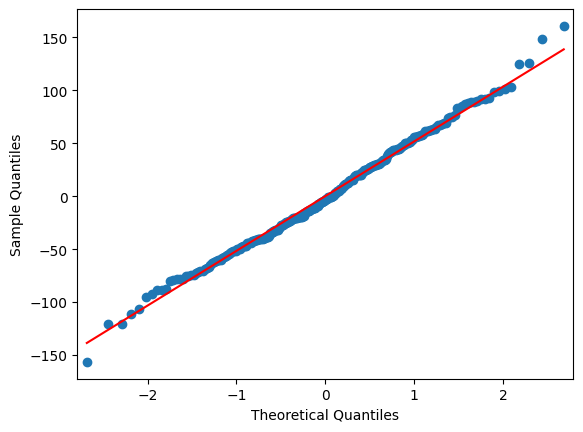

In [8]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson
fig = sm.qqplot(mdl_result.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(mdl_result.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(mdl_result.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [9]:
mdl_result.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                             chi2                  P>chi2  df constraint
Intercept  [[146.06793521766932]]  1.2545544190456466e-33              1
C(day)     [[30.970598822240568]]    9.49329148526628e-06              5
C(ttype)   [[5.5046084345884765]]    0.018966426314417417              1
C(cond)    [[19.078347053103702]]   7.197630959086227e-05              2

In [10]:
mdl_result.wald_test('C(cond)[T.sparse] = 0')

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[5.62673099]], p-value=0.01768858876570807, df_denom=1>

In [11]:
mdl_result.wald_test('C(cond)[T.ko]=0')

<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[18.79673923]], p-value=1.4541552757102814e-05, df_denom=1>

In [12]:
mdl_result.wald_test('C(cond)[T.sparse] = C(cond)[T.ko]')

<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[3.41146245]], p-value=0.06474504307257675, df_denom=1>

In [13]:
pg.pairwise_tests(data=df, dv='rzone_dat', between='cond', within='ttype', subject='mouse', parametric=False, padjust='holm')

,Contrast,ttype,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,ttype,-,fam,nov,True,False,NaN,100.0,two-sided,0.259452,NaN,NaN,-0.249250
1,cond,-,ctrl,ko,False,False,60.0,NaN,two-sided,0.001224,0.003671,holm,2.024189
2,cond,-,ctrl,sparse,False,False,50.0,NaN,two-sided,0.054895,0.109790,holm,1.172131
3,cond,-,ko,sparse,False,False,11.0,NaN,two-sided,0.097319,0.109790,holm,-0.914235
4,ttype * cond,fam,ctrl,ko,False,False,59.0,NaN,two-sided,0.002098,0.012587,holm,1.889196
5,ttype * cond,fam,ctrl,sparse,False,False,47.0,NaN,two-sided,0.114161,0.284615,holm,0.994306
6,ttype * cond,fam,ko,sparse,False,False,10.0,NaN,two-sided,0.072844,0.284615,holm,-1.107197
7,ttype * cond,nov,ctrl,ko,False,False,57.0,NaN,two-sided,0.005245,0.026224,holm,1.701970
8,ttype * cond,nov,ctrl,sparse,False,False,49.0,NaN,two-sided,0.071154,0.284615,holm,1.019131
9,ttype * cond,nov,ko,sparse,False,False,16.0,NaN,two-sided,0.317599,0.317599,holm,-0.613728


0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


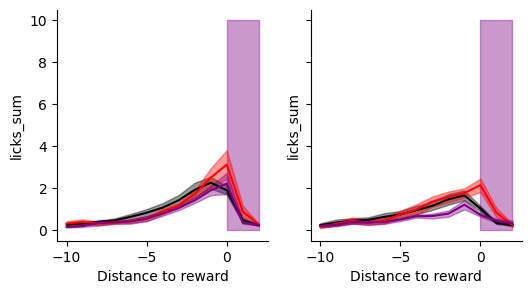

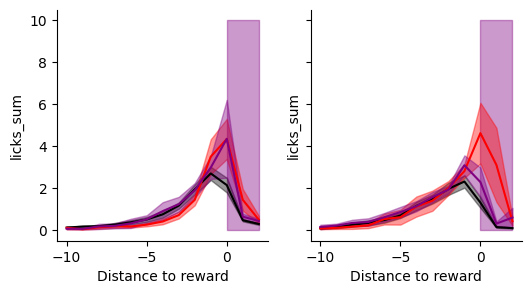

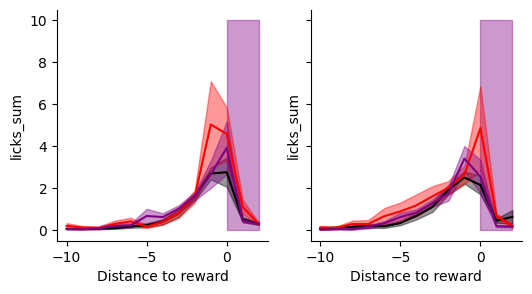

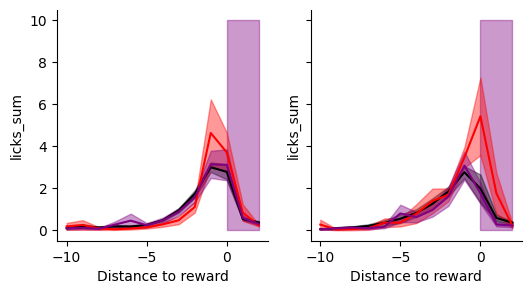

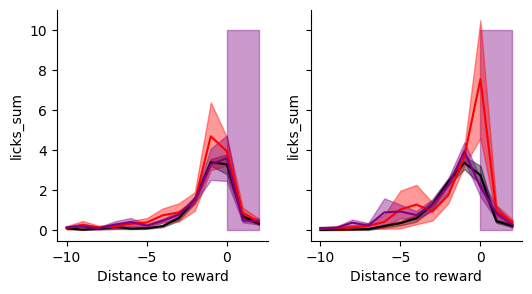

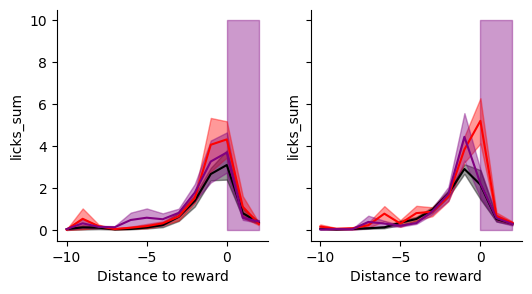

In [14]:
df = make_behavior_dataframe('licks_sum', mean=False)
plot_each_day(df,'licks_sum', maxy=10)

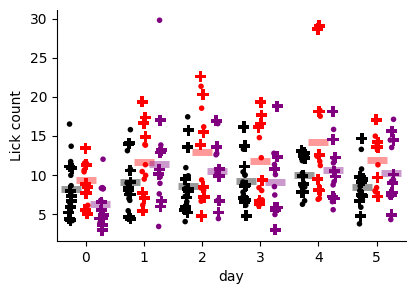

In [15]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='rzone_dat',
                hue='cond', 
                hue_order=('ctrl', 'ko','sparse'), 
                palette=['black', 'red','purple'],
                dodge=True,
                ax=ax, marker = marker, s=s,
                legend=False)
    


sns.pointplot(data=df,
            x='day',
            y='rzone_dat',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko', 'sparse'],
            dodge = .5,
            palette = ['black', 'red', 'purple'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
    # ax[i].set_title(nov)

# for a in ax:
ax.set_ylabel('Lick count')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


fig.savefig(figdir / "licks_sum_summary.pdf")


In [16]:
import statsmodels.formula.api as smf

df['rank_lick_rate'] = df['rzone_dat'].rank()
mdl = smf.mixedlm('rank_lick_rate ~   C(day) + C(ttype) + C(cond)', df, groups=df['mouse'])
mdl_result = mdl.fit()

mdl_result.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
================================================================
Model:              MixedLM  Dependent Variable:  rank_lick_rate
No. Observations:   274      Method:              REML          
No. Groups:         23       Scale:               3386.7101     
Min. group size:    10       Log-Likelihood:      -1493.3389    
Max. group size:    12       Converged:           Yes           
Mean group size:    11.9                                        
----------------------------------------------------------------
                   Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
----------------------------------------------------------------
Intercept           82.022   19.626  4.179 0.000  43.555 120.488
C(day)[T.1]         47.913   12.135  3.948 0.000  24.130  71.696
C(day)[T.2]         37.952   12.297  3.086 0.002  13.851  62.053
C(day)[T.3]         38.152   12.135  3.144 0.002  14.369  61.936
C(day)[T.4]         62.935   12.135  5.186 0.000  39.151  86.718
C(day)[T.5]         45.283   12.135  3.732 0.000  21.499  69.066
C(ttype)[T.nov]     -2.409    7.031 -0.343 0.732 -16.190  11.373
C(cond)[T.ko]       48.298   26.677  1.810 0.070  -3.989 100.585
C(cond)[T.sparse]    9.230   26.700  0.346 0.730 -43.100  61.561
Group Var         2520.042   15.859                             
================================================================

"""

In [17]:
mdl_result.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                              chi2                  P>chi2  df constraint
Intercept    [[17.46572144060534]]  2.9253498386669146e-05              1
C(day)       [[30.07241513232642]]  1.4272341721875584e-05              5
C(ttype)   [[0.11735437618216349]]      0.7319217862753815              1
C(cond)      [[3.523313293697151]]      0.1717600821980067              2

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


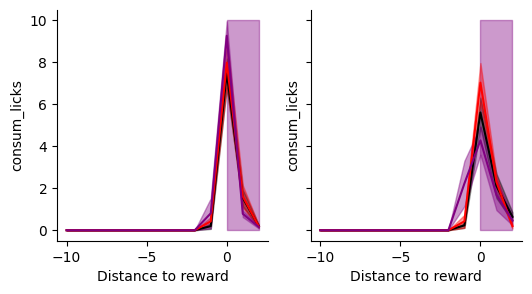

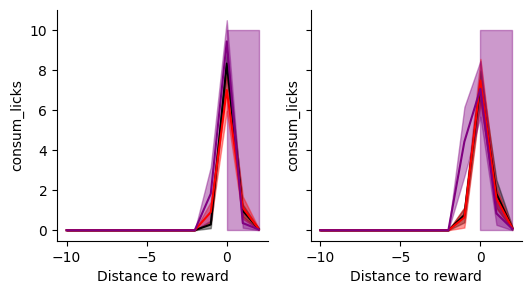

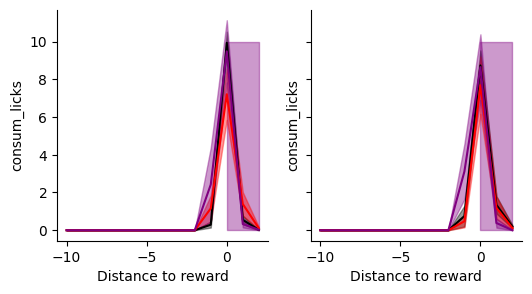

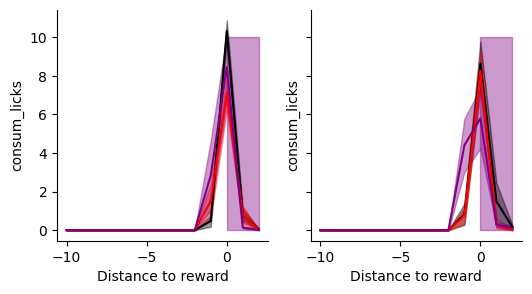

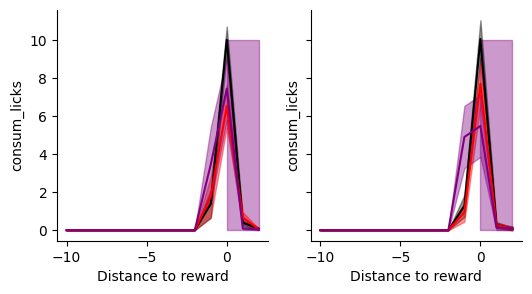

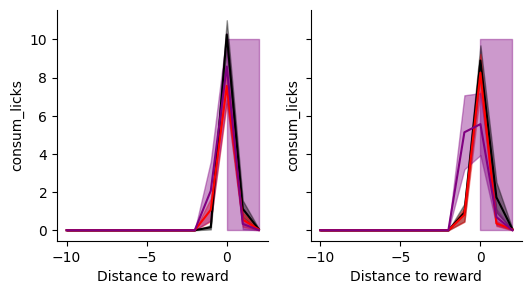

In [18]:
df = make_behavior_dataframe('consum_licks', mean=False)
plot_each_day(df,'consum_licks')

In [19]:


rows = []
x = np.arange(-10,3)
for (cond, mice) in zip(('ctrl', 'ko', 'sparse'), (ctrl_mice, ko_mice, sparse_mice)):
    for day in range(6):
        
        print(day)
        for mouse in mice:

            if mouse == 'SparseKO_09' and day==2:
                continue
            print(mouse)
            sess = stx.utilities.load_vr_day(mouse, day,verbose = False, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/', trial_mat_keys=['licks', 
                                                                                                                                'licks_sum', 
                                                                                                                                'nonconsum_licks', 
                                                                                                                                'consum_licks', 
                                                                                                                                'licks_rate', 'speed'])
            # if se
            # sess.novel_arm = stx.ymaze_sess_deets['']

            bin_edges = sess.trial_matrices['bin_edges']
            right_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
            left_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

            if sess.novel_arm==-1:
                rzone_nov = left_rzone_front
                rzone_fam = right_rzone_front
            else:
                rzone_nov = right_rzone_front
                rzone_fam = left_rzone_front

            for ttype in ('fam', 'nov'):
                
                if ttype == 'nov':
                    trial_mask = sess.trial_info["LR"] == sess.novel_arm
                    rzone = rzone_nov
                else:
                    trial_mask = sess.trial_info["LR"] != sess.novel_arm
                    rzone = rzone_fam

                
                licks = sess.trial_matrices['consum_licks'][trial_mask,:]
                
                rows.append({'cond': cond,
                            'mouse': mouse,
                            'day': day,
                            'ttype': ttype,
                            'licks': np.nansum(licks, axis=1).mean(axis=0),
                            })
df = pd.DataFrame(rows)
                    
                

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


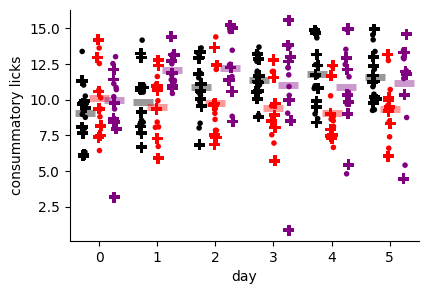

In [20]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='licks',
                hue='cond', 
                hue_order=('ctrl', 'ko','sparse'), 
                palette=['black', 'red','purple'],
                dodge=True,
                ax=ax, marker = marker, s=s,
                legend=False)
    


sns.pointplot(data=df,
            x='day',
            y='licks',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko', 'sparse'],
            dodge = .5,
            palette = ['black', 'red', 'purple'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
    # ax[i].set_title(nov)

# for a in ax:
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('consummatory licks')


fig.savefig(figdir / "consum_licks_summary.pdf")


In [21]:
import statsmodels.formula.api as smf

df['rank_licks'] = df['licks'].rank()
mdl = smf.mixedlm('rank_licks ~   C(day) + C(ttype) + C(cond)', df, groups=df['mouse'])
mdl_result = mdl.fit()

mdl_result.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
              Mixed Linear Model Regression Results
=================================================================
Model:               MixedLM    Dependent Variable:    rank_licks
No. Observations:    274        Method:                REML      
No. Groups:          23         Scale:                 2783.5108 
Min. group size:     10         Log-Likelihood:        -1470.9801
Max. group size:     12         Converged:             Yes       
Mean group size:     11.9                                        
-----------------------------------------------------------------
                   Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
-----------------------------------------------------------------
Intercept          117.130   20.705  5.657 0.000   76.549 157.710
C(day)[T.1]         24.652   11.001  2.241 0.025    3.091  46.214
C(day)[T.2]         39.332   11.148  3.528 0.000   17.482  61.182
C(day)[T.3]         38.065   11.001  3.460 0.001   16.504  59.627
C(day)[T.4]         32.022   11.001  2.911 0.004   10.460  53.583
C(day)[T.5]         39.413   11.001  3.583 0.000   17.851  60.975
C(ttype)[T.nov]     -3.606    6.375 -0.566 0.572  -16.100   8.888
C(cond)[T.ko]      -43.229   29.003 -1.490 0.136 -100.074  13.616
C(cond)[T.sparse]   21.584   29.020  0.744 0.457  -35.294  78.462
Group Var         3080.204   20.648                              
=================================================================

"""

In [22]:
mdl_result.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                             chi2                  P>chi2  df constraint
Intercept   [[32.00268123815763]]  1.5395993233412828e-08              1
C(day)     [[19.182580982181783]]    0.001777266017069413              5
C(ttype)    [[0.319970855536187]]      0.5716251602332572              1
C(cond)     [[4.629201020258872]]     0.09880564797439839              2

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


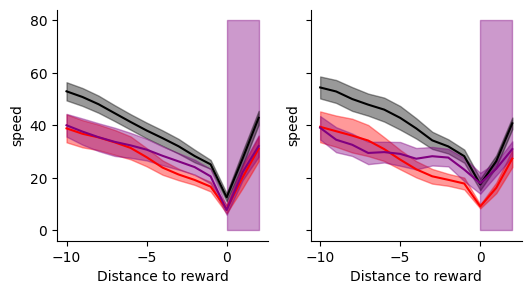

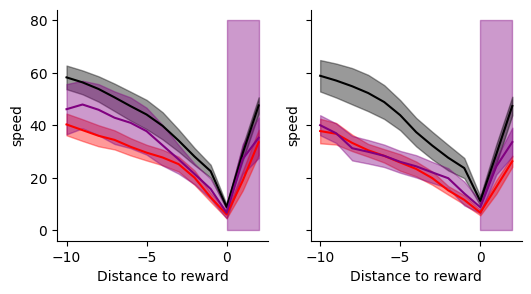

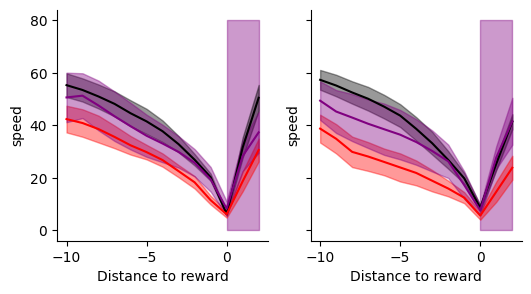

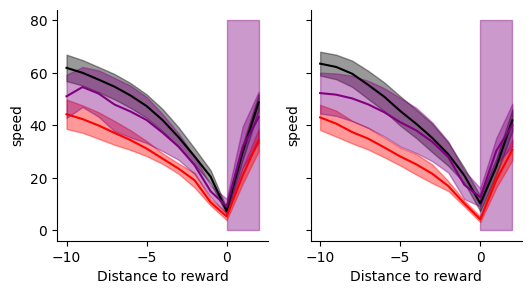

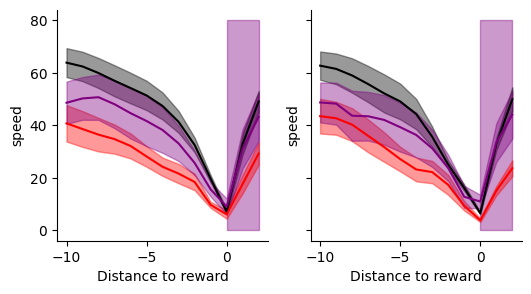

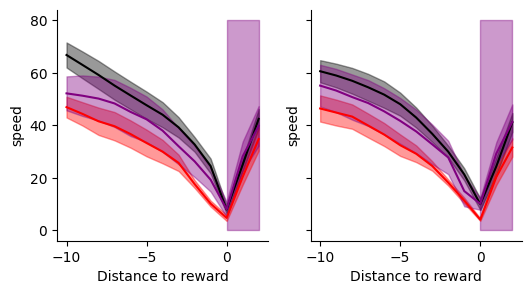

In [23]:
df = make_behavior_dataframe('speed', mean=True)
plot_each_day(df,'speed',maxy=80)

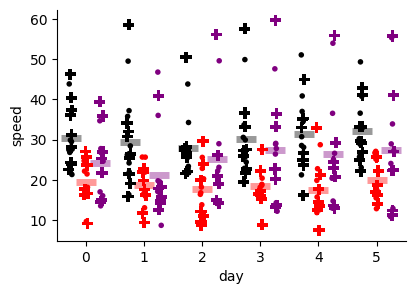

In [24]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='rzone_dat',
                hue='cond', 
                hue_order=('ctrl', 'ko','sparse'), 
                palette=['black', 'red','purple'],
                dodge=True,
                ax=ax, marker = marker, s=s,
                legend=False)
    


sns.pointplot(data=df,
            x='day',
            y='rzone_dat',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko', 'sparse'],
            dodge = .5,
            palette = ['black', 'red', 'purple'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
    # ax[i].set_title(nov)

# for a in ax:
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('speed')


fig.savefig(figdir / "speed_summary.pdf")


In [25]:
rows = []
for (cond, mice) in zip(('ctrl', 'ko', 'sparse'), (ctrl_mice, ko_mice, sparse_mice)):
    for day in range(6):
        
        print(day)
        for mouse in mice:

            if mouse == 'SparseKO_09' and day==2:
                continue
            print(mouse)
            sess = stx.utilities.load_vr_day(mouse, day,verbose = False, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/', trial_mat_keys=['licks', 
                                                                                                                                'licks_sum', 
                                                                                                                                'nonconsum_licks', 
                                                                                                                                'consum_licks', 
                                                                                                                                'licks_rate', 'speed'])
            # if se
            # sess.novel_arm = stx.ymaze_sess_deets['']

            bin_edges = sess.trial_matrices['bin_edges']
            right_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
            left_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

            if sess.novel_arm==-1:
                rzone_nov = left_rzone_front
                rzone_fam = right_rzone_front
            else:
                rzone_nov = right_rzone_front
                rzone_fam = left_rzone_front

            for ttype in ('fam', 'nov'):
                
                if ttype == 'nov':
                    trial_mask = sess.trial_info["LR"] == sess.novel_arm
                    rzone = rzone_nov
                else:
                    trial_mask = sess.trial_info["LR"] != sess.novel_arm
                    rzone = rzone_fam

                
                cv = sp.stats.variation(sess.trial_matrices['speed'][trial_mask,:],axis=0, nan_policy='omit')
                rzone_plot_vec = cv[rzone-10:rzone+3]
                # print(cv)
                rows.append({'cond': cond,
                            'mouse': mouse,
                            'day': day,
                            'ttype': ttype,
                            'rzone_dat': cv[rzone-5:rzone+1].mean(),
                            'rzone_plot_vec': rzone_plot_vec,
                            })
df = pd.DataFrame(rows)

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


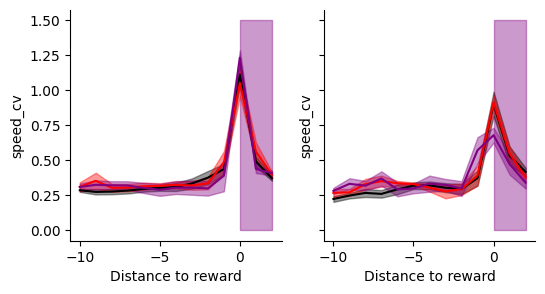

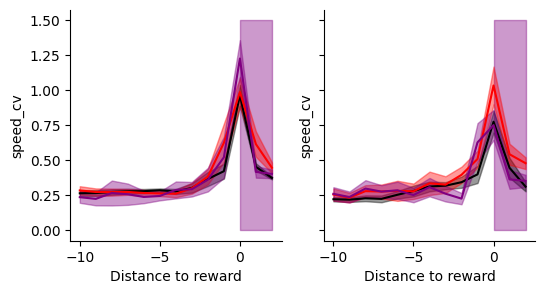

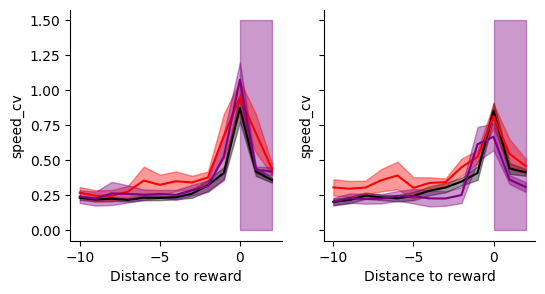

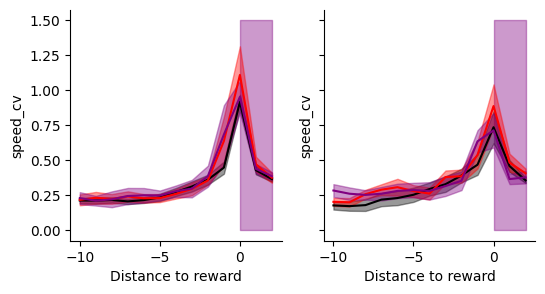

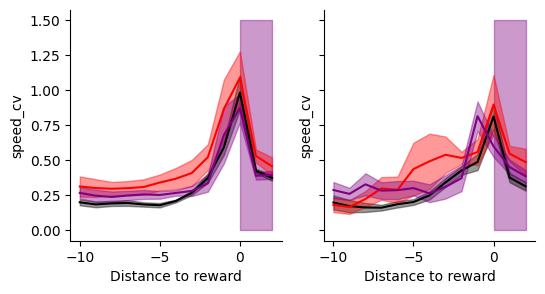

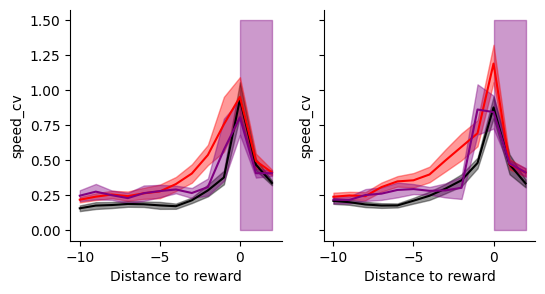

In [26]:
plot_each_day(df,'speed_cv',maxy=1.5)

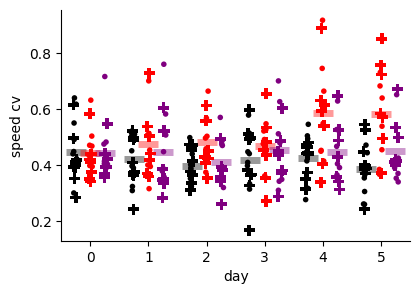

In [27]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='rzone_dat',
                hue='cond', 
                hue_order=('ctrl', 'ko','sparse'), 
                palette=['black', 'red','purple'],
                dodge=True,
                ax=ax, marker = marker, s=s,
                legend=False)
    


sns.pointplot(data=df,
            x='day',
            y='rzone_dat',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko', 'sparse'],
            dodge = .5,
            palette = ['black', 'red', 'purple'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
    # ax[i].set_title(nov)

# for a in ax:
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('speed cv')


fig.savefig(figdir / "speed_summary.pdf")


In [28]:
import statsmodels.formula.api as smf

df['rank_speedcv'] = df['rzone_dat'].rank()
mdl = smf.mixedlm('rank_speedcv ~   C(day) + C(ttype) * C(cond)', df, groups=df['mouse'])
mdl_result = mdl.fit()

mdl_result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                     Mixed Linear Model Regression Results
================================================================================
Model:                    MixedLM        Dependent Variable:        rank_speedcv
No. Observations:         274            Method:                    REML        
No. Groups:               23             Scale:                     4441.8256   
Min. group size:          10             Log-Likelihood:            -1513.9912  
Max. group size:          12             Converged:                 Yes         
Mean group size:          11.9                                                  
--------------------------------------------------------------------------------
                                   Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------------
Intercept                          119.245   18.231  6.541 0.000  83.514 154.977
C(day)[T.1]                         -4.174   13.897 -0.300 0.764 -31.411  23.063
C(day)[T.2]                        -15.355   14.080 -1.091 0.275 -42.952  12.242
C(day)[T.3]                         -0.109   13.897 -0.008 0.994 -27.346  27.129
C(day)[T.4]                         16.130   13.897  1.161 0.246 -11.107  43.368
C(day)[T.5]                          3.370   13.897  0.242 0.808 -23.868  30.607
C(ttype)[T.nov]                     -4.278   12.826 -0.334 0.739 -29.417  20.861
C(cond)[T.ko]                       60.635   23.988  2.528 0.011  13.619 107.650
C(cond)[T.sparse]                   18.821   24.047  0.783 0.434 -28.310  65.952
C(ttype)[T.nov]:C(cond)[T.ko]      -11.603   19.391 -0.598 0.550 -49.610  26.403
C(ttype)[T.nov]:C(cond)[T.sparse]  -16.722   19.524 -0.856 0.392 -54.989  21.544
Group Var                         1525.415    9.396                             
================================================================================

"""

In [29]:
mdl_result.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                    chi2                 P>chi2  df constraint
Intercept         [[42.783578927689575]]  6.114326844250696e-11              1
C(day)             [[5.310556935991995]]     0.3791662102691043              5
C(ttype)          [[0.1112342940900986]]     0.7387432617180493              1
C(cond)            [[6.516273438228347]]   0.038459993065944546              2
C(ttype):C(cond)  [[0.7966576944365816]]     0.6714411897855326              2

In [30]:
mdl_result.wald_test('C(cond)[T.sparse]=0')

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[0.61260787]], p-value=0.43380758840115696, df_denom=1>

In [31]:
mdl_result.wald_test('C(cond)[T.ko]=0')

<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[6.38940133]], p-value=0.011480374072996557, df_denom=1>

In [32]:
mdl_result.wald_test('C(cond)[T.sparse]=C(cond)[T.ko]')

<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[2.68908301]], p-value=0.10103794498324657, df_denom=1>

Shapiro-Wilk: W=0.989, p=0.0319
D'Agostino: χ²=14.790, p=0.000614


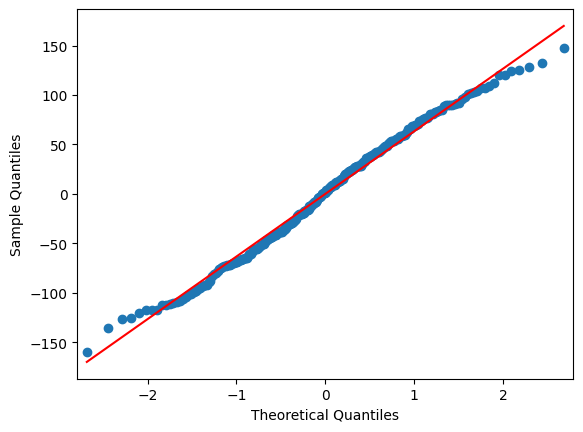

In [33]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson
fig = sm.qqplot(mdl_result.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(mdl_result.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(mdl_result.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [34]:
import pickle

with open('/home/mplitt/shuffle_pkls/licks_sum_mixedlm_shuffle.pkl', 'rb') as file:
    res_dict = pickle.load(file)

In [35]:
res_dict.keys()

dict_keys(['rzone_licks', 'rzone_licks_rank'])

In [36]:
for stat in res_dict.keys():
    coef = res_dict[stat]['genotype coef.']
    shuff_coef = res_dict[stat]['shuffle genotype coef.']

    p = (1.*(coef<shuff_coef)).sum()/shuff_coef.shape[0]
    p = np.minimum(p, 1-p)
    print(f"{stat} : p={p}")

rzone_licks : p=0.05139860139860142
rzone_licks_rank : p=0.048164335664335645


### Only omission trial licks sum vs lick rate, accounting for speed

In [31]:

def make_rzone_dataframe(lick_key, mean=False, omit_only =False):
    rows = []
    x = np.arange(-10,3)
    for (cond, mice) in zip(('ctrl', 'ko', 'sparse'), (ctrl_mice, ko_mice, sparse_mice)):
        for day in range(6):
            
            print(day)
            for mouse in mice:

                if mouse == 'SparseKO_09' and day==2:
                    continue
                print(mouse)
                sess = stx.utilities.load_vr_day(mouse, day,verbose = False, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/', trial_mat_keys=['licks', 
                                                                                                                                    'licks_sum', 
                                                                                                                                    'nonconsum_licks', 
                                                                                                                                    'consum_licks', 
                                                                                                                                    'licks_rate', 
                                                                                                                                    'speed', 
                                                                                                                                    'reward'])
                # if se
                # sess.novel_arm = stx.ymaze_sess_deets['']

                bin_edges = sess.trial_matrices['bin_edges']
                right_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
                left_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

                if sess.novel_arm==-1:
                    rzone_nov = left_rzone_front
                    rzone_fam = right_rzone_front
                else:
                    rzone_nov = right_rzone_front
                    rzone_fam = left_rzone_front

                for ttype in ('fam', 'nov'):
                    
                    if ttype == 'nov':
                        trial_mask = sess.trial_info["LR"] == sess.novel_arm
                        rzone = rzone_nov
                    else:
                        trial_mask = sess.trial_info["LR"] != sess.novel_arm
                        rzone = rzone_fam

                    if omit_only:
                        trial_mask = trial_mask & (np.nansum(sess.trial_matrices['reward'],axis=1)==0)

                    
                    licks = sess.trial_matrices[lick_key][trial_mask,:]
                    speed = sess.trial_matrices['speed'][trial_mask,:]
                    if mean:
                        rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
                    else:
                        rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).sum()

                    rzone_speed = np.nanmean(speed[:,rzone-5:rzone+3], axis=0).mean()   
                    rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)

                    rows.append({'cond': cond,
                                'mouse': mouse,
                                'day': day,
                                'ttype': ttype,
                                'rzone_dat': rzone_dat,
                                'rzone_plot_vec': rzone_plot_vec,
                                'rzone_speed': rzone_speed,
                                })
    return pd.DataFrame(rows)
                    
                

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8


/tmp/ipykernel_201590/3043990390.py:52: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).sum()
/tmp/ipykernel_201590/3043990390.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-5:rzone+3], axis=0).mean()
/tmp/ipykernel_201590/3043990390.py:55: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_201590/3043990390.py:52: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).sum()
/tmp/ipykernel_201590/3043990390.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-5:rzone+3], axis=0).mean()
/tmp/ipykernel_201590/3043990390.py:55: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_201590/3043990390.py:52: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).sum()
/tmp/ip

mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8


/tmp/ipykernel_201590/3043990390.py:52: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).sum()
/tmp/ipykernel_201590/3043990390.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-5:rzone+3], axis=0).mean()
/tmp/ipykernel_201590/3043990390.py:55: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_201590/3043990390.py:52: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).sum()
/tmp/ipykernel_201590/3043990390.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-5:rzone+3], axis=0).mean()
/tmp/ipykernel_201590/3043990390.py:55: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_201590/3043990390.py:52: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).sum()
/tmp/ip

mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3


...

4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11


/tmp/ipykernel_201590/3043990390.py:52: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).sum()
/tmp/ipykernel_201590/3043990390.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-5:rzone+3], axis=0).mean()
/tmp/ipykernel_201590/3043990390.py:55: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_201590/3043990390.py:52: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).sum()
/tmp/ipykernel_201590/3043990390.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-5:rzone+3], axis=0).mean()
/tmp/ipykernel_201590/3043990390.py:55: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_201590/3043990390.py:52: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).sum()
/tmp/ip

SparseKO_13
SparseKO_09
1
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
2
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
3
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11


/tmp/ipykernel_201590/3043990390.py:52: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).sum()
/tmp/ipykernel_201590/3043990390.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-5:rzone+3], axis=0).mean()
/tmp/ipykernel_201590/3043990390.py:55: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_201590/3043990390.py:52: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).sum()
/tmp/ipykernel_201590/3043990390.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-5:rzone+3], axis=0).mean()
/tmp/ipykernel_201590/3043990390.py:55: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)


SparseKO_13
SparseKO_09
4
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
5
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09


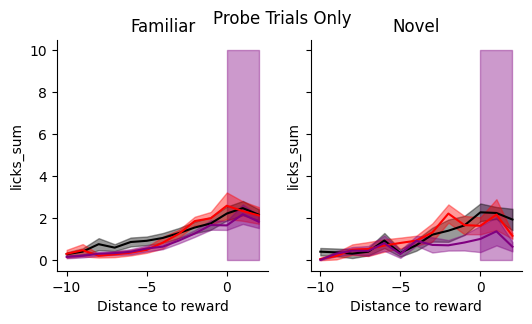

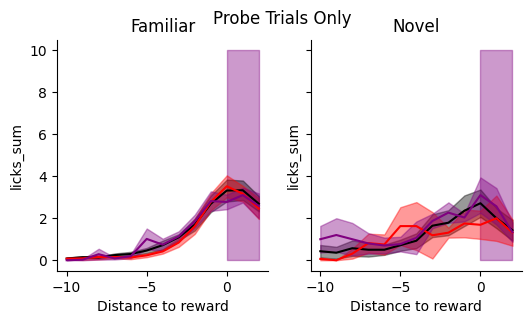

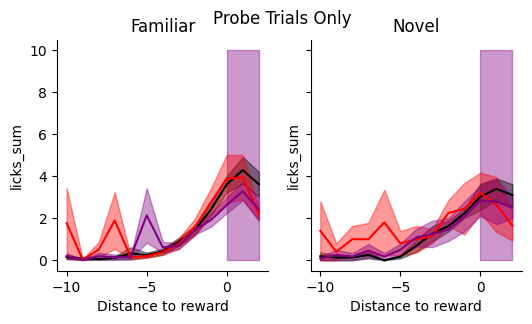

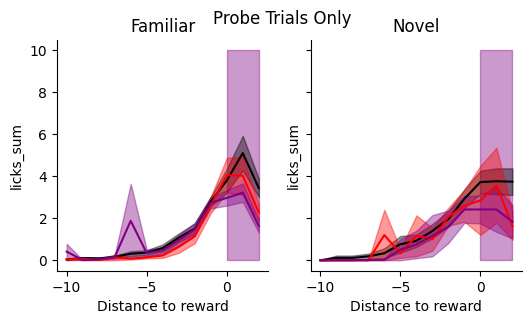

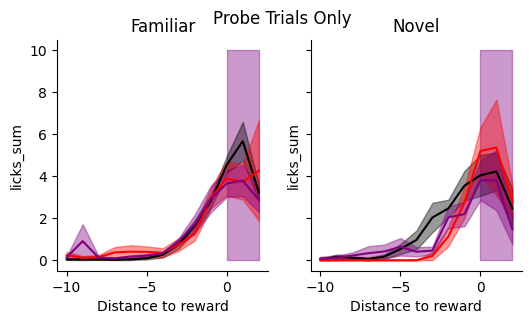

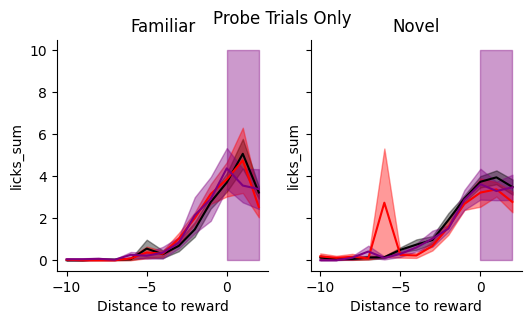

In [32]:
df = make_rzone_dataframe('licks_sum', mean=False, omit_only=True)
plot_each_day(df,'licks_sum', maxy=10,save=True)

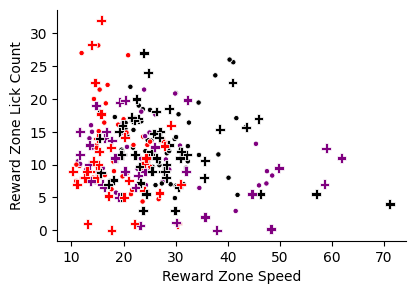

In [33]:
fig,ax = plt.subplots(figsize=[4.5,3], sharey = True, sharex=True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 50
    else:
        marker = '.'
        s = 60
    for day in range(6):
        sns.scatterplot(data=df.loc[(df['ttype']==nov) & (df['day']==day),:],
                    x='rzone_speed',
                    y='rzone_dat',
                    hue='cond', 
                    hue_order=('ctrl', 'ko','sparse'), 
                    palette=['black', 'red','purple'],
                    # dodge=True,
                    ax=ax, marker = marker,  s=s,
                    legend=False)
        
# for a in ax.flatten():
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Reward Zone Speed')
ax.set_ylabel('Reward Zone Lick Count')
fig.savefig(figdir / "probe_trial_licks_sum_v_rzone_speed.pdf")

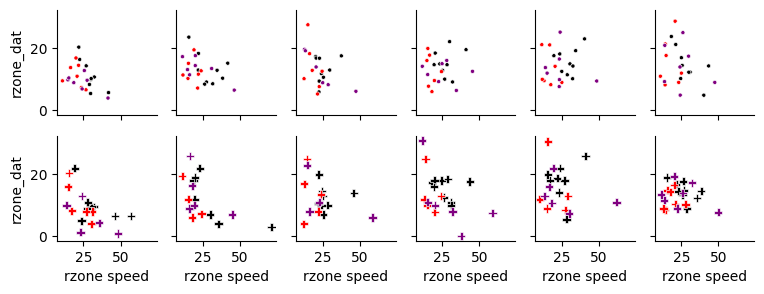

In [29]:
fig,ax = plt.subplots(2,6, figsize=[9,3], sharey = True, sharex=True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 15
    else:
        marker = '.'
        s = 15
    for day in range(6):
        sns.scatterplot(data=df.loc[(df['ttype']==nov) & (df['day']==day),:],
                    x='rzone_speed',
                    y='rzone_dat',
                    hue='cond', 
                    hue_order=('ctrl', 'ko','sparse'), 
                    palette=['black', 'red','purple'],
                    # dodge=True,
                    ax=ax[i,day], marker = marker, # s=s,
                    legend=False)
        
for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_xlabel('rzone speed')
# ax[0].set_ylabel('rzone lick count')

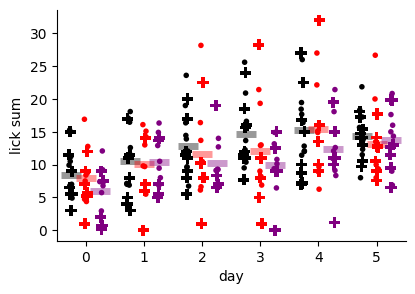

In [34]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='rzone_dat',
                hue='cond', 
                hue_order=('ctrl', 'ko','sparse'), 
                palette=['black', 'red','purple'],
                dodge=True,
                ax=ax, marker = marker, s=s,
                legend=False)
    


sns.pointplot(data=df,
            x='day',
            y='rzone_dat',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko', 'sparse'],
            dodge = .5,
            palette = ['black', 'red', 'purple'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
    # ax[i].set_title(nov)

# for a in ax:
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('lick sum')
fig.savefig(figdir / "probe_trial_licks_sum_summary.pdf")



In [8]:
import pickle
with open('/home/mplitt/shuffle_pkls/probe_trial_licks_sum_mixedlm_shuffle.pkl', 'rb') as file:
        model_shuff_results = pickle.load(file)

for stat in model_shuff_results.keys():

    true_coef = model_shuff_results[stat]['genotype coef.']
    shuff_coefs = model_shuff_results[stat]['shuffle genotype coef.']
    p = (true_coef>shuff_coefs).sum()/float(shuff_coefs.shape[0])
    print(f"{stat} true coef = {true_coef}, p = {p} ")



rzone_licks true coef = -4.33143649508223, p = 0.028409090909090908 
rzone_licks_rank true coef = -38.04198722714136, p = 0.038636363636363635 


In [9]:
model_shuff_results['rzone_licks_rank']['true_model'].wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                            chi2                 P>chi2  df constraint
Intercept                  [[61.69037785117776]]  4.019396806663983e-15              1
C(ttype)                  [[1.8274076147864284]]    0.17643405221875402              1
C(day)                    [[17.027761149345118]]   0.004447447013403996              5
C(cond)                    [[2.442634508745138]]     0.1180777659726869              1
C(ttype):C(day)           [[3.4195651243974625]]     0.6355918475712964              5
C(ttype):C(cond)         [[0.31094864284723084]]     0.5770986428212914              1
C(day):C(cond)             [[4.580366927369871]]    0.46920315355159026              5
C(ttype):C(day):C(cond)   [[3.0766561816702334]]      0.688168865115232              5
rzone_speed_rank            [[74.4242347891197]]  6.301071038818981e-18              1

In [10]:
df = df.dropna()

In [11]:
import statsmodels.formula.api as smf

df['rank_lick_sum'] = df['rzone_dat'].rank()
df['rank_speed'] = df['rzone_speed'].rank()
df_tmp = df.copy()
# df_tmp = df_tmp[df_tmp['ttype'] == 'fam']
# mdl = smf.mixedlm('rank_lick_sum ~   C(day) +  C(cond) + C(ttype) ', df, groups=df['mouse'])
# mdl = smf.mixedlm('rank_lick_sum ~   C(day) +  C(cond) + C(ttype) + rzone_speed', df, groups=df['mouse'])
mdl = smf.mixedlm('rank_lick_sum ~   C(day) *  C(cond) * C(ttype) + rank_speed', df_tmp, groups=df_tmp['mouse'])
mdl_result = mdl.fit()

mdl_result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                            Mixed Linear Model Regression Results
==============================================================================================
Model:                         MixedLM            Dependent Variable:            rank_lick_sum
No. Observations:              251                Method:                        REML         
No. Groups:                    23                 Scale:                         1993.7577    
Min. group size:               8                  Log-Likelihood:                -1184.1162   
Max. group size:               12                 Converged:                     Yes          
Mean group size:               10.9                                                           
----------------------------------------------------------------------------------------------
                                               Coef.   Std.Err.    z    P>|z|  [0.025   0.975]
----------------------------------------------------------------------------------------------
Intercept                                      215.514   24.974   8.630 0.000  166.566 264.462
C(day)[T.1]                                     20.923   21.069   0.993 0.321  -20.371  62.217
C(day)[T.2]                                     19.066   21.194   0.900 0.368  -22.474  60.606
C(day)[T.3]                                     53.949   21.081   2.559 0.010   12.631  95.267
C(day)[T.4]                                     72.863   21.049   3.462 0.001   31.608 114.119
C(day)[T.5]                                     45.049   21.065   2.139 0.032    3.762  86.336
C(cond)[T.ko]                                  -52.694   33.971  -1.551 0.121 -119.276  13.888
C(cond)[T.sparse]                              -69.909   33.724  -2.073 0.038 -136.007  -3.811
C(ttype)[T.nov]                                -28.255   21.752  -1.299 0.194  -70.888  14.377
C(day)[T.1]:C(cond)[T.ko]                      -13.125   31.826  -0.412 0.680  -75.503  49.253
C(day)[T.2]:C(cond)[T.ko]                      -13.211   31.860  -0.415 0.678  -75.657  49.234
C(day)[T.3]:C(cond)[T.ko]                      -49.093   31.824  -1.543 0.123 -111.467  13.281
C(day)[T.4]:C(cond)[T.ko]                      -55.815   31.903  -1.750 0.080 -118.345   6.714
C(day)[T.5]:C(cond)[T.ko]                      -18.412   31.834  -0.578 0.563  -80.806  43.981
C(day)[T.1]:C(cond)[T.sparse]                   35.946   31.826   1.129 0.259  -26.432  98.324
C(day)[T.2]:C(cond)[T.sparse]                   24.909   32.693   0.762 0.446  -39.169  88.986
C(day)[T.3]:C(cond)[T.sparse]                   -4.589   31.892  -0.144 0.886  -67.096  57.917
C(day)[T.4]:C(cond)[T.sparse]                   -8.025   31.824  -0.252 0.801  -70.399  54.350
C(day)[T.5]:C(cond)[T.sparse]                   45.357   31.859   1.424 0.155  -17.085 107.800
C(day)[T.1]:C(ttype)[T.nov]                     -5.910   31.442  -0.188 0.851  -67.534  55.715
C(day)[T.2]:C(ttype)[T.nov]                     21.558   30.782   0.700 0.484  -38.773  81.889
C(day)[T.3]:C(ttype)[T.nov]                     33.742   30.273   1.115 0.265  -25.593  93.077
C(day)[T.4]:C(ttype)[T.nov]                      1.662   30.937   0.054 0.957  -58.974  62.297
C(day)[T.5]:C(ttype)[T.nov]                     34.405   30.277   1.136 0.256  -24.938  93.747
C(cond)[T.ko]:C(ttype)[T.nov]                   13.272   33.120   0.401 0.689  -51.641  78.185
C(cond)[T.sparse]:C(ttype)[T.nov]                1.294   34.179   0.038 0.970  -65.695  68.283
C(day)[T.1]:C(cond)[T.ko]:C(ttype)[T.nov]      -44.591   49.047  -0.909 0.363 -140.723  51.540
C(day)[T.2]:C(cond)[T.ko]:C(ttype)[T.nov]      -20.694   47.617  -0.435 0.664 -114.021  72.632
C(day)[T.3]:C(cond)[T.ko]:C(ttype)[T.nov]      -42.837   47.331  -0.905 0.365 -135.604  49.931
C(day)[T.4]:C(cond)[T.ko]:C(ttype)[T.nov]       20.554   47.632   0.432 0.666  -72.803 113.911
C(day)[T.5]:C(cond)[T.ko]:C(ttype)[T.nov]      -39.436   45.917  -0.859 0.390 -129.43

Shapiro-Wilk: W=0.991, p=0.142
D'Agostino: χ²=3.768, p=0.152


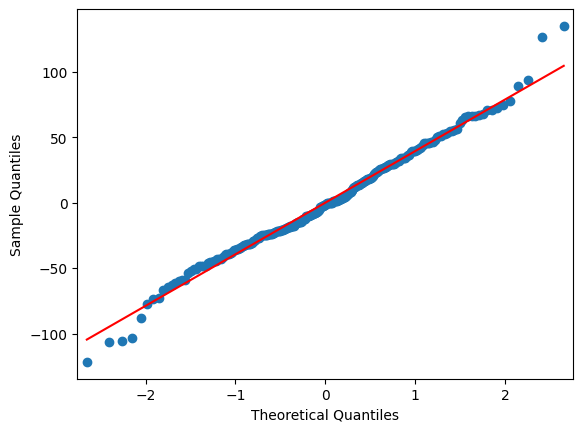

In [12]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson
fig = sm.qqplot(mdl_result.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(mdl_result.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(mdl_result.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [13]:
mdl_result.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                            chi2                 P>chi2  df constraint
Intercept                  [[74.46968744212742]]  6.157653186513256e-18              1
C(day)                    [[16.101402690524335]]   0.006560449602693358              5
C(cond)                    [[4.785386700391776]]    0.09138322509937055              2
C(ttype)                   [[1.687383109795594]]     0.1939462923976054              1
C(day):C(cond)             [[9.406631169556512]]    0.49399580243166374             10
C(day):C(ttype)             [[3.42418083820252]]     0.6348897892582905              5
C(cond):C(ttype)         [[0.18108849190455695]]     0.9134339172533106              2
C(day):C(cond):C(ttype)   [[3.5762531738080474]]     0.9644455836352597             10
rank_speed                [[100.81247782873511]]  1.011173087539326e-23              1

In [91]:
mdl_result.wald_test('C(cond)[T.sparse] = 0')

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[5.34385122]], p-value=0.020795481872928425, df_denom=1>

In [92]:
mdl_result.wald_test('C(cond)[T.ko]=0')

<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[9.41954828]], p-value=0.002146844000564033, df_denom=1>

In [94]:
mdl_result.wald_test('C(cond)[T.ko]=C(cond)[T.sparse]')

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[0.58482185]], p-value=0.4444284928470259, df_denom=1>

In [35]:
pg.pairwise_tests(data=df.loc[df['cond']!='sparse'], dv='rzone_dat', between='cond', within='day', subject='mouse', parametric=False, padjust='holm')

,Contrast,day,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,day,-,0,1,True,False,NaN,21.0,two-sided,0.013092,0.104736,holm,-0.652131
1,day,-,0,2,True,False,NaN,5.0,two-sided,0.000305,0.003967,holm,-0.906534
2,day,-,0,3,True,False,NaN,8.0,two-sided,0.000763,0.009155,holm,-1.143846
3,day,-,0,4,True,False,NaN,1.0,two-sided,0.000061,0.000916,holm,-1.441123
4,day,-,0,5,True,False,NaN,2.0,two-sided,0.000092,0.001282,holm,-1.527047
5,day,-,1,2,True,False,NaN,40.0,two-sided,0.159058,0.648651,holm,-0.404450
6,day,-,1,3,True,False,NaN,30.0,two-sided,0.050659,0.303955,holm,-0.599631
7,day,-,1,4,True,False,NaN,12.0,two-sided,0.002136,0.023499,holm,-0.964042
8,day,-,1,5,True,False,NaN,13.0,two-sided,0.002686,0.026855,holm,-0.851572
9,day,-,2,3,True,False,NaN,44.0,two-sided,0.231201,0.693604,holm,-0.139039
